# Associative Recall Inference on Pretrained Models

This notebook runs **inference only** on existing pretrained checkpoints using the sequence-length benchmark pipeline with `task_variant="associative_recall"`.

No model training is performed.

## Runtime Notes

- Downloads can take time the first run (W&B checkpoints).
- Start small (`num_repetitions`, `seqlen_list`, number of models), then scale up.

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
from IPython.display import display

from pfns.utils import get_default_device
from pfns.experiments.model_benchmarks.analysis import (
    compute_mean_rank_tables,
    nested_metric_table_to_long_df,
)
from pfns.experiments.model_benchmarks.evaluation import evaluate_models_over_seqlens
from pfns.experiments.model_benchmarks.io import make_bundle_path, save_results_bundle
from pfns.experiments.model_benchmarks.model_registry import (
    get_autocast_models_from_registry,
    get_forward_models_from_registry,
    get_models_from_families,
    get_models_from_names,
)
from pfns.experiments.model_benchmarks.models import load_models_for_benchmark
import torch



/home/david/miniconda3/envs/icl_arch_311/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/david/miniconda3/envs/icl_arch_311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
EXPERIMENT = {
    "name": "ar_inference_pretrained",
    "num_classes": 5,
    "num_features": 10,
    "num_test_samples": 100,
    "num_repetitions": 100,
    "data_generation_seed": 42,
    "use_warmup_iters": False,
    "print_timing": False,
    "seqlen_list": [128, 512, 2048, 8192],
    "task_variant": "associative_recall",
    "task_kwargs": {},
}

# Choose ONE mode:
MODEL_SELECTION_MODE = "names"  # "names" | "families"

MODEL_NAMES = [
    "equal_params:Transformer_Comb_ST",
    "equal_params:DeltaNet_Comb_ST",
    "equal_params:GLA_Comb_ST",
]

MODEL_FAMILIES = ["equal_params"]

if MODEL_SELECTION_MODE == "names":
    models_to_compare = get_models_from_names(MODEL_NAMES)
else:
    models_to_compare = get_models_from_families(MODEL_FAMILIES)

print(f"Selected {len(models_to_compare)} model(s):")
for name in models_to_compare:
    print(" -", name)

display(pd.DataFrame.from_dict(models_to_compare, orient="index"))

AR_ADAPT = {
    "enabled": False,  # Set True to adapt models on AR before evaluation
    "max_steps": 100_000,
    # Sample eval_position uniformly each step in [min_train_seqlen, max_train_seqlen].
    "max_train_seqlen": 1000,
    "min_train_seqlen": 128,
    "num_test_samples": 128,
    "lr": 5e-5,
    "weight_decay": 0.0,
    "grad_clip": 1.0,
    "log_every": 100,
    "model_names": None,  # None = all loaded models
    # Early stopping controls (evaluated on synthetic AR validation batches)
    "early_stopping": True,
    "eval_every": 1000,
    "val_batches": 32,
    "patience_evals": 5,
    "min_delta": 2e-4,
    "restore_best": True,
}


Selected 3 model(s):
 - equal_params:Transformer_Comb_ST
 - equal_params:DeltaNet_Comb_ST
 - equal_params:GLA_Comb_ST


,display_name,wandb_run_id,eval_autocast_dtype
equal_params:Transformer_Comb_ST,Transformer_Comb_ST,tabpfn_transformer/runs/nb5hz44b,NaN
equal_params:DeltaNet_Comb_ST,DeltaNet_Comb_ST,fla_models/runs/ob2m9rth,bf16
equal_params:GLA_Comb_ST,GLA_Comb_ST,fla_models/runs/4vsqz1ee,NaN


In [3]:
device = str(get_default_device())
print("Using device:", device)

models, configs = load_models_for_benchmark(models_to_compare, device=device)
autocast_models = get_autocast_models_from_registry(models_to_compare, device=device)
forward_models = get_forward_models_from_registry(models_to_compare)

print("Loaded models:", list(models.keys()))
print("Autocast models:", list(autocast_models.keys()))
print("Forward-only models:", forward_models)

Using device: cuda:0
Attempting to download model from wandb run: tabpfn_transformer/runs/nb5hz44b


wandb: Currently logged in as: dschnurr (icl_arch) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Model at PFNs/models_diff/transformer_config_0_training_setup_high_nb5hz44b/checkpoint.pt is already up to date (Run ID: nb5hz44b, Epoch: 200). Skipping download.
Attempting to download model from wandb run: fla_models/runs/ob2m9rth
Model at PFNs/models_diff/fla_config_0_model_type_deltanet_sequence_mode_cached_training_setup_high_ob2m9rth/checkpoint.pt is already up to date (Run ID: ob2m9rth, Epoch: 200). Skipping download.
Attempting to download model from wandb run: fla_models/runs/4vsqz1ee


/home/david/miniconda3/envs/icl_arch_311/lib/python3.11/site-packages/fla/layers/delta_net.py:154: UserWarning: ShortConvolution is crucial to the performance. Do not turn it off, i.e., setting `use_short_conv=False` unless you know what you are doing.
  warnings.warn(


Model at PFNs/models_diff/fla_config_0_model_type_gla_sequence_mode_cached_training_setup_high_4vsqz1ee/checkpoint.pt is already up to date (Run ID: 4vsqz1ee, Epoch: 200). Skipping download.
Loaded models: ['equal_params:Transformer_Comb_ST', 'equal_params:DeltaNet_Comb_ST', 'equal_params:GLA_Comb_ST']
Autocast models: ['equal_params:DeltaNet_Comb_ST']
Forward-only models: []


In [4]:
# Optional AR adaptation
# Prefer using the existing training infrastructure via `pfns/run_training_cli.py`
# with config arg `task_variant="associative_recall"`.
adapt_histories = {}
if AR_ADAPT["enabled"]:
    print(
        "In-notebook AR adaptation is disabled. "
        "Train via run_training_cli + task_variant='associative_recall', then reload checkpoints."
    )


Adapting equal_params:Transformer_Comb_ST on AR... (autocast=None)


AR adapt:  12%|█▏        | 5999/50000 [01:55<14:06, 52.01it/s, train_loss=0.0001, val_loss=0.0000, best_val=0.0000, best_step=1000, status=early_stop]


Adapting equal_params:DeltaNet_Comb_ST on AR... (autocast=torch.bfloat16)


AR adapt:  60%|█████▉    | 29999/50000 [20:33<13:42, 24.32it/s, train_loss=0.0409, val_loss=0.3274, best_val=0.2815, best_step=25000, status=early_stop]


Adapting equal_params:GLA_Comb_ST on AR... (autocast=None)


AR adapt:  34%|███▍      | 16999/50000 [09:23<18:14, 30.16it/s, train_loss=0.7056, val_loss=1.2145, best_val=1.1880, best_step=12000, status=early_stop]

equal_params:Transformer_Comb_ST: final_step=6000, best_step=1000, start=1.6099, end=0.0001, best_val=1.8013222096158188e-06
equal_params:DeltaNet_Comb_ST: final_step=30000, best_step=25000, start=1.5919, end=0.0409, best_val=0.2814881228841841
equal_params:GLA_Comb_ST: final_step=17000, best_step=12000, start=1.5921, end=0.7056, best_val=1.1880302987992764


In [5]:
results = evaluate_models_over_seqlens(
    models=models,
    configs=configs,
    seqlen_list=EXPERIMENT["seqlen_list"],
    num_features=EXPERIMENT["num_features"],
    num_classes=EXPERIMENT["num_classes"],
    number_of_test_samples=EXPERIMENT["num_test_samples"],
    number_of_repetitions=EXPERIMENT["num_repetitions"],
    use_warmup_iters=EXPERIMENT["use_warmup_iters"],
    print_timing=EXPERIMENT["print_timing"],
    autocast_models=autocast_models,
    forward_models=forward_models,
    device=device,
    data_generation_seed=EXPERIMENT["data_generation_seed"],
    task_variant=EXPERIMENT["task_variant"],
    task_kwargs=EXPERIMENT["task_kwargs"],
    progress_desc="AR inference",
)

results["metadata"]

AR inference: 100%|██████████| 100/100 [00:40<00:00,  2.47it/s]


{'seqlen_list': [128, 512, 2048, 8192],
 'num_features': 10,
 'num_classes': 5,
 'number_of_test_samples': 100,
 'number_of_repetitions': 100,
 'device': 'cuda:0',
 'forward_models': [],
 'data_generation_seed': 42,
 'task_variant': 'associative_recall',
 'task_kwargs': {}}

In [6]:
metric_df = nested_metric_table_to_long_df(results["metric_table"])
timing_df = nested_metric_table_to_long_df(results["timing_table"])
memory_df = nested_metric_table_to_long_df(results["memory_table"])

print("metric_df:", metric_df.shape)
print("timing_df:", timing_df.shape)
print("memory_df:", memory_df.shape)

display(metric_df.head())
display(timing_df.head())
display(memory_df.head())

metric_df: (3600, 5)
timing_df: (3600, 5)
memory_df: (3600, 5)


,model,metric,seqlen,rep,value
1200,equal_params:DeltaNet_Comb_ST,acc,128,0,1.00
1201,equal_params:DeltaNet_Comb_ST,acc,128,1,0.99
1202,equal_params:DeltaNet_Comb_ST,acc,128,2,1.00
1203,equal_params:DeltaNet_Comb_ST,acc,128,3,0.98
1204,equal_params:DeltaNet_Comb_ST,acc,128,4,1.00


,model,metric,seqlen,rep,value
1600,equal_params:DeltaNet_Comb_ST,fit_time_ms,128,0,6.817216
1601,equal_params:DeltaNet_Comb_ST,fit_time_ms,128,1,7.086048
1602,equal_params:DeltaNet_Comb_ST,fit_time_ms,128,2,6.673376
1603,equal_params:DeltaNet_Comb_ST,fit_time_ms,128,3,7.025568
1604,equal_params:DeltaNet_Comb_ST,fit_time_ms,128,4,6.948192


,model,metric,seqlen,rep,value
2000,equal_params:DeltaNet_Comb_ST,context_size_mb,128,0,1.171875
2001,equal_params:DeltaNet_Comb_ST,context_size_mb,128,1,1.171875
2002,equal_params:DeltaNet_Comb_ST,context_size_mb,128,2,1.171875
2003,equal_params:DeltaNet_Comb_ST,context_size_mb,128,3,1.171875
2004,equal_params:DeltaNet_Comb_ST,context_size_mb,128,4,1.171875


In [7]:
metric_summary = (
    metric_df.groupby(["model", "metric"], observed=True)["value"]
    .agg(mean="mean", std="std")
    .reset_index()
)
display(metric_summary.sort_values(["metric", "mean"], ascending=[True, False]))

rank_tables = compute_mean_rank_tables(metric_df)
display(rank_tables["overall_ranks"].sort_values(["metric", "rank"]))

,model,metric,mean,std
6,equal_params:Transformer_Comb_ST,acc,0.979950,0.038991
0,equal_params:DeltaNet_Comb_ST,acc,0.702900,0.259542
3,equal_params:GLA_Comb_ST,acc,0.425350,0.211252
4,equal_params:GLA_Comb_ST,ce,1.291979,0.393045
1,equal_params:DeltaNet_Comb_ST,ce,0.720580,0.602039
7,equal_params:Transformer_Comb_ST,ce,0.059766,0.109880
8,equal_params:Transformer_Comb_ST,roc_auc,0.999101,0.002433
2,equal_params:DeltaNet_Comb_ST,roc_auc,0.878373,0.141096
5,equal_params:GLA_Comb_ST,roc_auc,0.712093,0.162363


,metric,model,rank
2,acc,equal_params:Transformer_Comb_ST,1.0
0,acc,equal_params:DeltaNet_Comb_ST,2.0
1,acc,equal_params:GLA_Comb_ST,3.0
5,ce,equal_params:Transformer_Comb_ST,1.0
3,ce,equal_params:DeltaNet_Comb_ST,2.0
4,ce,equal_params:GLA_Comb_ST,3.0
8,roc_auc,equal_params:Transformer_Comb_ST,1.0
6,roc_auc,equal_params:DeltaNet_Comb_ST,2.0
7,roc_auc,equal_params:GLA_Comb_ST,3.0


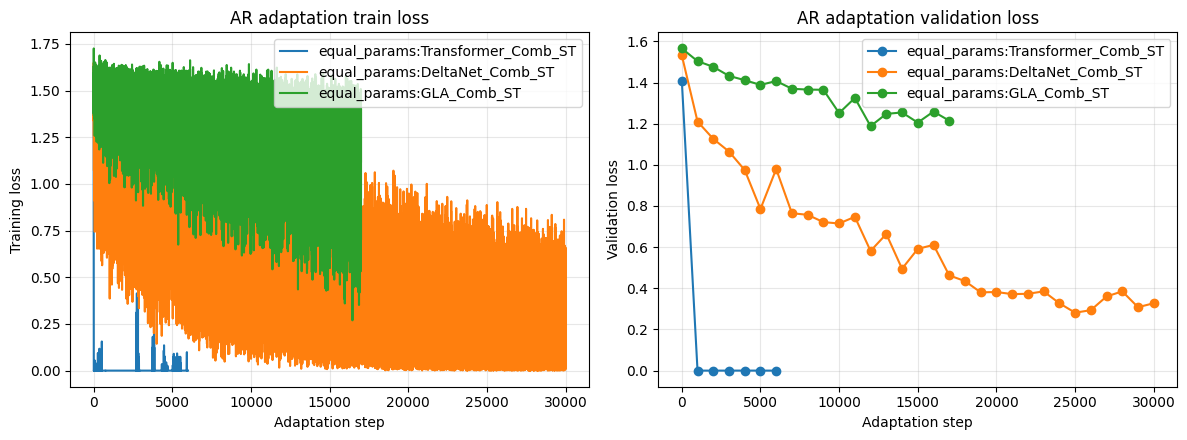

In [8]:
# Optional: visualize AR adaptation loss curves
if adapt_histories:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for model_name, hist in adapt_histories.items():
        train_losses = hist.get("train_losses", [])
        if not train_losses:
            continue
        axes[0].plot(range(1, len(train_losses) + 1), train_losses, label=model_name)

        val_hist = hist.get("val_history", [])
        if val_hist:
            val_x = [s for s, _ in val_hist]
            val_y = [v for _, v in val_hist]
            axes[1].plot(val_x, val_y, marker="o", label=model_name)

    axes[0].set_xlabel("Adaptation step")
    axes[0].set_ylabel("Training loss")
    axes[0].set_title("AR adaptation train loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc="best")

    axes[1].set_xlabel("Adaptation step")
    axes[1].set_ylabel("Validation loss")
    axes[1].set_title("AR adaptation validation loss")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc="best")

    plt.tight_layout()
    plt.show()


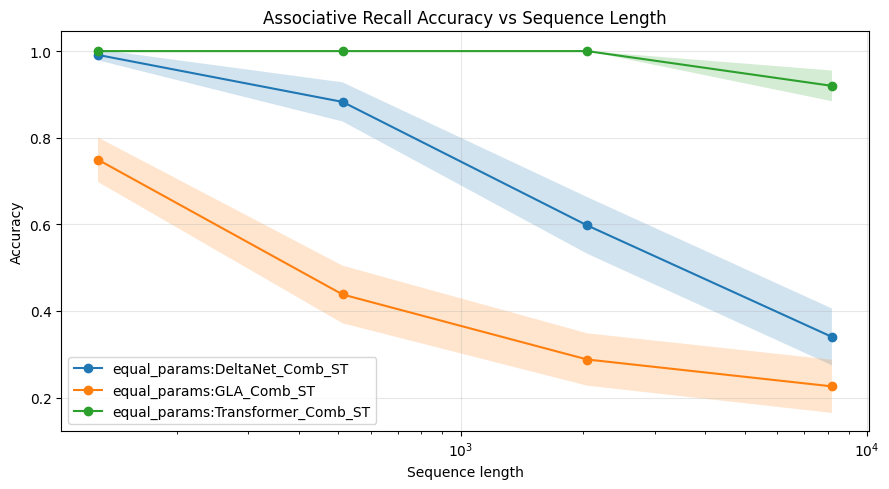

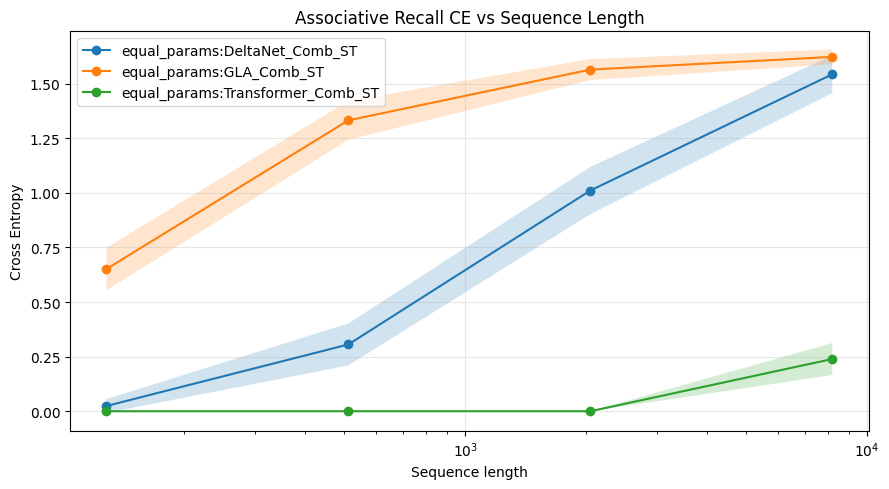

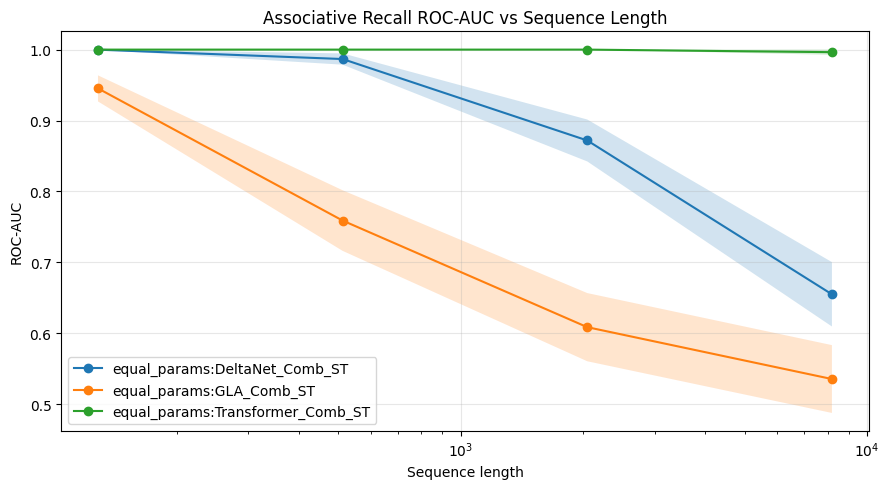

In [9]:
import matplotlib.pyplot as plt

def _plot_metric_by_seqlen(df, metric_name, title, y_label):
    metric_slice = df[df["metric"] == metric_name].copy()
    if metric_slice.empty:
        print(f"No rows for metric={metric_name!r}.")
        return

    summary = (
        metric_slice.groupby(["model", "seqlen"], observed=True)["value"]
        .agg(mean="mean", std="std")
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    for model_name, g in summary.groupby("model", observed=True):
        g = g.sort_values("seqlen")
        x = g["seqlen"].to_numpy()
        y = g["mean"].to_numpy()
        y_std = g["std"].fillna(0.0).to_numpy()
        ax.plot(x, y, marker="o", label=model_name)
        ax.fill_between(x, y - y_std, y + y_std, alpha=0.2)

    ax.set_xscale("log")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel(y_label)
    ax.set_title(title)

    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

_plot_metric_by_seqlen(metric_df, "acc", "Associative Recall Accuracy vs Sequence Length", "Accuracy")
_plot_metric_by_seqlen(metric_df, "ce", "Associative Recall CE vs Sequence Length", "Cross Entropy")
_plot_metric_by_seqlen(metric_df, "roc_auc", "Associative Recall ROC-AUC vs Sequence Length", "ROC-AUC")


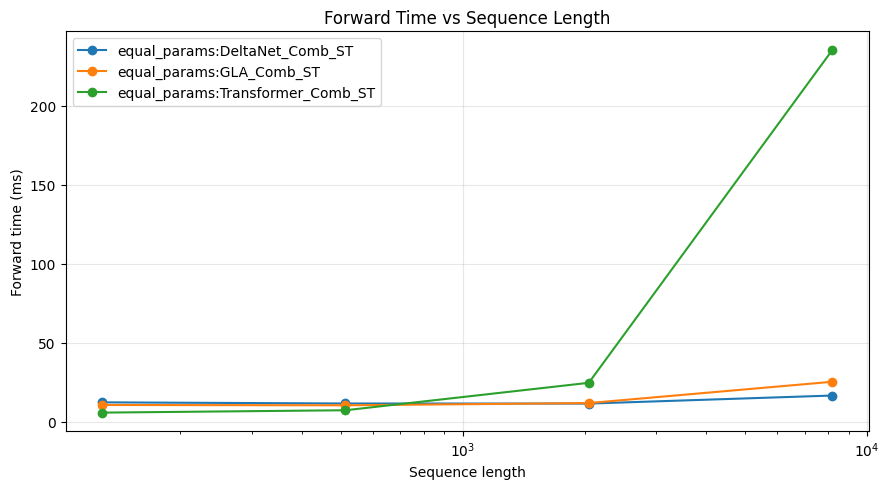

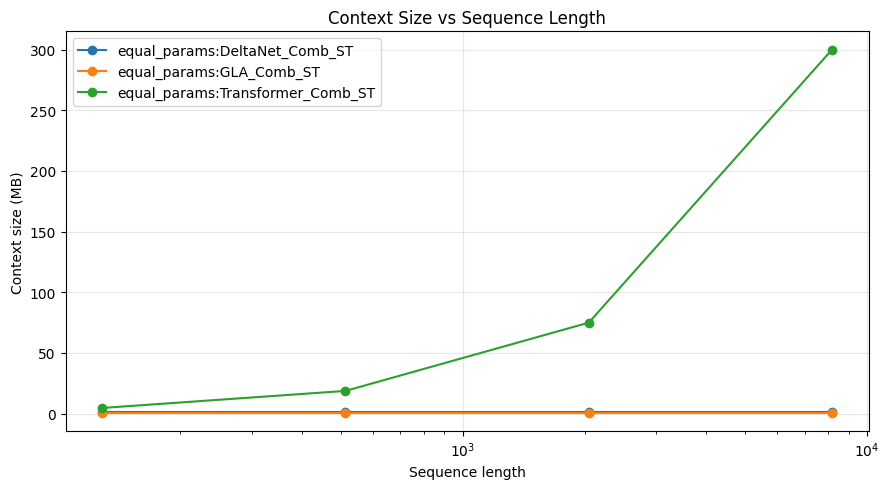

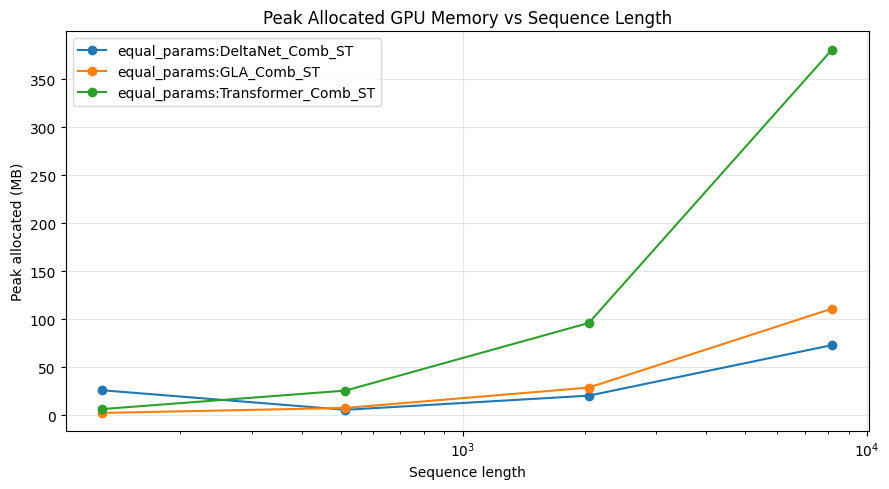

In [10]:
def _plot_system_by_seqlen(df, metric_name, title, y_label):
    metric_slice = df[df["metric"] == metric_name].copy()
    if metric_slice.empty:
        print(f"No rows for metric={metric_name!r}.")
        return

    summary = (
        metric_slice.groupby(["model", "seqlen"], observed=True)["value"]
        .agg(mean="mean", std="std")
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    for model_name, g in summary.groupby("model", observed=True):
        g = g.sort_values("seqlen")
        x = g["seqlen"].to_numpy()
        y = g["mean"].to_numpy()
        y_std = g["std"].fillna(0.0).to_numpy()
        ax.plot(x, y, marker="o", label=model_name)
        ax.fill_between(x, y - y_std, y + y_std, alpha=0.2)

    ax.set_xscale("log")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

_plot_system_by_seqlen(timing_df, "forward_time_ms", "Forward Time vs Sequence Length", "Forward time (ms)")
_plot_system_by_seqlen(memory_df, "context_size_mb", "Context Size vs Sequence Length", "Context size (MB)")
_plot_system_by_seqlen(memory_df, "peak_allocated_mb", "Peak Allocated GPU Memory vs Sequence Length", "Peak allocated (MB)")


In [11]:
# Optional: persist result bundle.
output_root = Path.cwd() / "exp_outputs" / "seq_len_associative_recall_inference"
output_root.mkdir(parents=True, exist_ok=True)
bundle_path = make_bundle_path(output_root, EXPERIMENT["name"])
save_results_bundle(results, bundle_path, experiment=EXPERIMENT, include_raw_torch=True)
bundle_path

PosixPath('/home/david/ICL-Architectures/PFNs/notebooks/exp_outputs/seq_len_associative_recall_inference/ar_inference_pretrained_20260226_204310')